# Collate Eckstein et al synpase predictions

In [1]:
# Add auto reload
%load_ext autoreload
%autoreload 2

In [2]:
#libraries
import os
import numpy as np
import pandas as pd
from decouple import config, Config, RepositoryEnv
from caveclient import CAVEclient
from fafbseg import flywire
from getpass import getpass
import seaborn as sns
import matplotlib.pyplot as plt
import navis

# Get variables from the .env file
ENV_PATH = "../.env"
config = Config(RepositoryEnv(ENV_PATH))
# Get the CAVE_AUTH_TOKEN
cave_token = config("CAVE_AUTH_TOKEN", default=None)
if not cave_token:
    print("No CAVE token found in the .env file.")
    temp_token = getpass("Token not found in the .env file. Please enter your CAVE token (if you don't have one leave if blank and instructions will appear): ")
    if temp_token:
        cave_token = temp_token
    else:
        print("No CAVE token entered. Follow the information below to get a token.")
        CAVEclient.auth.get_new_token()

if cave_token:
    # Initialize the CAVE client
    client = CAVEclient('flywire_fafb_public')
    auth = client.auth
    auth.save_token(cave_token)

/opt/anaconda3/envs/fau_connectomics/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ValueError: Key "token" already exists in token file "/Users/marcusleiwe/.cloudvolume/secrets/global.daf-apis.com-cave-secret.json"

In [ ]:
# Get the FLYWIRE_AUTH_TOKEN
flywire_token = config("FLYWIRE_AUTH_TOKEN", default=None)

#Save the secret
flywire.set_chunkedgraph_secret(flywire_token)

ValueError: Key "token" already exists in token file "/Users/marcusleiwe/.cloudvolume/secrets/global.daf-apis.com-cave-secret.json"

In [4]:
root_id= "720575940624928574"
pre_df = client.materialize.query_table(
    table='synapses_nt_v1',
    filter_in_dict={'pre_pt_root_id': [root_id]},
)

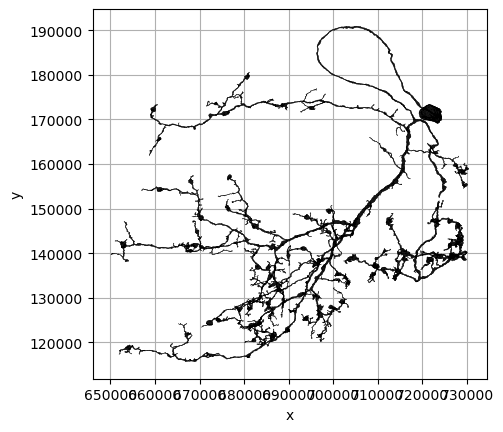

Process ForkPoolWorker-2:
Process ForkPoolWorker-3:
Process ForkPoolWorker-5:
Process ForkPoolWorker-1:
Process ForkPoolWorker-4:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/opt/anaconda3/envs/fau_connectomics/lib/python3.12/site-packages/multiprocess/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/fau_connectomics/lib/python3.12/site-packages/multiprocess/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/fau_connectomics/lib/python3.12/site-packages/multiprocess/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/fau_connectomics/lib/python3.12/site-packages/multiprocess/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/fau_connectomics/lib/python3.12/site-packages/multiprocess/process.py", line 108, in ru

In [6]:
# Neuron Mesh
neuron_mesh = flywire.get_mesh_neuron(root_id)
fig, ax = navis.plot2d(neuron_mesh, color='k')

In [8]:
pre_df

,id,created,superceded_id,valid,connection_score,cleft_score,gaba,ach,glut,oct,ser,da,valid_nt,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_position,post_pt_position
0,214660960,2021-03-09 20:14:58.183080+00:00,NaN,t,178.443710,146,0.573427,0.012797,0.357354,3.171137e-02,1.120479e-02,1.350511e-02,t,82192342869822207,720575940624928574,82192342869815634,720575940619434712,"[672464, 123968, 128240]","[672424, 123856, 128200]"
1,117358129,2021-03-09 20:14:58.183080+00:00,NaN,t,541.228027,142,0.912269,0.000142,0.087586,5.496258e-07,4.089258e-07,8.404323e-07,t,82896305189929007,720575940624928574,82896305189918198,720575940627196691,"[716104, 138956, 142000]","[716116, 139084, 142000]"
2,212755160,2021-03-09 20:14:58.183080+00:00,NaN,t,63.837860,0,0.002260,0.000186,0.004339,1.661167e-02,3.335109e-02,9.432522e-01,t,83037592433525500,720575940624928574,83037592433526880,720575940631766339,"[722744, 172224, 124160]","[722836, 172388, 124160]"
3,117340484,2021-03-09 20:14:58.183080+00:00,NaN,t,314.917725,46,0.035379,0.177907,0.616214,7.871953e-04,5.352731e-02,1.161863e-01,t,82825867726245398,720575940624928574,82825867726241325,720575940622726271,"[709816, 136728, 142040]","[709752, 136656, 142080]"
4,7854637,2021-03-09 20:14:58.183080+00:00,NaN,t,304.986511,146,0.722328,0.008425,0.268439,2.831123e-04,2.782840e-04,2.462957e-04,t,82825867792827755,720575940624928574,82825867792751588,720575940645673508,"[708872, 134976, 144720]","[708960, 134924, 144720]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2766,10743551,2021-03-09 20:14:58.183080+00:00,NaN,t,655.441223,150,0.941407,0.005157,0.051837,2.727648e-05,6.850158e-04,8.867508e-04,t,82474092590510391,720575940624928574,82474092590497553,720575940623922615,"[690212, 139336, 96520]","[690344, 139308, 96480]"
2767,40985835,2021-03-09 20:14:58.183080+00:00,NaN,t,93.763893,0,0.002389,0.006210,0.027201,6.384544e-01,1.675431e-01,1.582020e-01,t,82334042430942262,720575940624928574,82334042430935605,720575940625926693,"[680560, 179820, 130640]","[680452, 179976, 130680]"
2768,147201533,2021-03-09 20:14:58.183080+00:00,NaN,t,181.298172,158,0.186410,0.013800,0.085931,3.683391e-03,2.395421e-02,6.862214e-01,t,82755773792818138,720575940624928574,82755773792822932,720575940630964311,"[707976, 150860, 118800]","[707856, 150800, 118800]"
2769,215603760,2021-03-09 20:14:58.183080+00:00,NaN,t,37.649769,71,0.679009,0.003916,0.314808,1.086263e-05,1.679569e-03,5.772178e-04,t,82474642480252425,720575940624928574,82474642480269032,720575940624911548,"[688704, 173464, 128880]","[688728, 173572, 128920]"


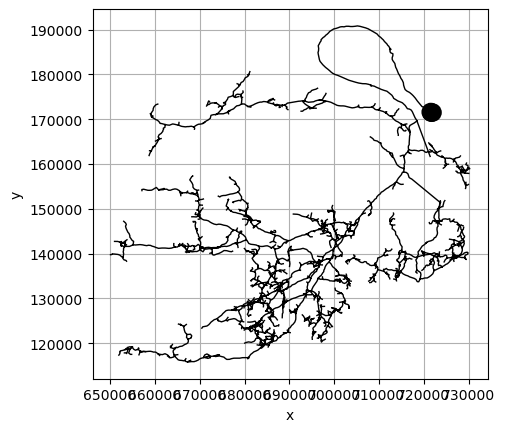

In [7]:
# Neuron Skeleton
neuron_skeleton = flywire.get_skeletons(root_id)
fig, ax = navis.plot2d(neuron_skeleton, color='k')

/var/folders/6f/d2f9mt417y32sjcfd4zvfwdh0000gn/T/ipykernel_5938/55544027.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['', 'GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA'], rotation=45)


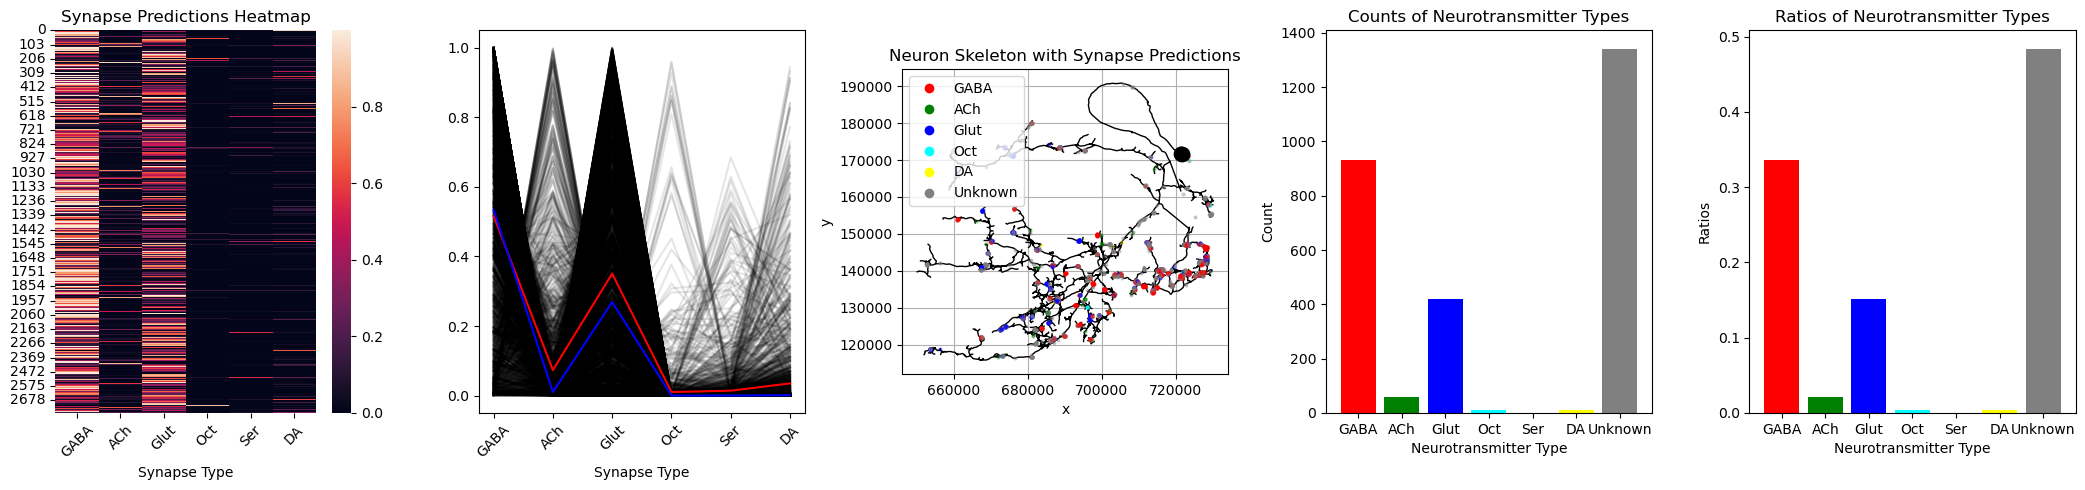

In [ ]:
def get_synapse_predictions(root_id, client, softmax_threshold=0.75):
    """
    Function to gather synapse predictions for a given root ID.
    Returns a DataFrame containing the synapse predictions alongside a N*6 array of the synapse predictions.
    """
    # 
    pre_df = client.materialize.query_table(
        table='synapses_nt_v1',
        filter_in_dict={'pre_pt_root_id': [root_id]},
    )

    # Now create an array of the synapse predictions
    synapse_predictions = np.zeros((len(pre_df), 6), dtype=np.float32)
    for i in range(pre_df.shape[0]):
        row = [pre_df.iloc[i]['gaba'], pre_df.iloc[i]['ach'], pre_df.iloc[i]['glut'], pre_df.iloc[i]['oct'], pre_df.iloc[i]['ser'], pre_df.iloc[i]['da']]
        synapse_predictions[i] = row
    # print(f"synapse_predictions: {synapse_predictions}")

    # Get the skeleton for the neuron
    neuron_skeleton = flywire.get_skeletons(root_id)
    
    #Now plot everything
    fig, ax = plt.subplots(1,5, figsize=(21, 5))

    # Plot the synapse predictions as a heatmap
    sns.heatmap(synapse_predictions, ax=ax[0])
    ax[0].set_title('Synapse Predictions Heatmap')
    ax[0].set_xlabel('Synapse Type')
    ax[0].set_xticklabels(['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA'], rotation=45)

    # Plot each row of the synapse predictions as a line plot
    for i in range(synapse_predictions.shape[0]):
        ax[1].plot(synapse_predictions[i], color='k', label=f'Synapse {i+1}', alpha=0.1)

    mean_predictions = np.mean(synapse_predictions, axis=0)
    median_predictions = np.median(synapse_predictions, axis=0)
    ax[1].plot(mean_predictions, label='Mean', color='r')
    ax[1].plot(median_predictions, label='Median', color='blue')

    ax[1].set_xlabel('Synapse Type')
    ax[1].set_xticklabels(['', 'GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA'], rotation=45)

    # Plot the neuron skeleton with the synapse predictions
    navis.plot2d(neuron_skeleton, ax=ax[2], color='k')
    
    # Define neurotransmitter types and colors
    nt_types = ['GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA', 'Unknown']
    colors = ['red', 'green', 'blue', 'cyan', 'magenta', 'yellow', 'gray']
    
    # Keep track of which neurotransmitter types are present for the legend
    present_types = set()

    nt_counts = {
        'GABA': 0,
        'ACh': 0,
        'Glut': 0,
        'Oct': 0,
        'Ser': 0,
        'DA': 0,
        'Unknown': 0
    }
    
    for i in range(synapse_predictions.shape[0]):
        # Determine the synapse type based on the maximum prediction value  
        synapse_type = np.argmax(synapse_predictions[i])
        softmax_val = np.max(synapse_predictions[i])
        if softmax_val < softmax_threshold:
            synapse_type = 6  # Assign 'Unknown' if below threshold
        color = colors[synapse_type]
        present_types.add(synapse_type)
        
        # Increment the count for the neurotransmitter type
        nt_counts[nt_types[synapse_type]] += 1

        # Find the position of the pre-synapse
        pos = pre_df.iloc[i]['pre_pt_position']
        pos_xy = (pos[0], pos[1])
        
        # Plot the synapse prediction on the neuron skeleton
        ax[2].plot(pos_xy[0], pos_xy[1], 'o', color=color, markersize=2, alpha=0.33)
    
    # Create legend entries only for neurotransmitter types that are present
    legend_elements = []
    for nt_idx in sorted(present_types):
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                        markerfacecolor=colors[nt_idx], markersize=8,
                                        label=nt_types[nt_idx]))
    
    ax[2].legend(handles=legend_elements, loc='best')
    ax[2].set_title('Neuron Skeleton with Synapse Predictions')

    # Plot the counts of each neurotransmitter type
    ax[3].bar(nt_counts.keys(), nt_counts.values(), color=colors)
    ax[3].set_xlabel('Neurotransmitter Type')
    ax[3].set_ylabel('Count')
    ax[3].set_title('Counts of Neurotransmitter Types')

    # Plot the counts of each neurotransmitter type
    pcts = [nt_counts[nt] / synapse_predictions.shape[0] for nt in nt_counts.keys()]
    ax[4].bar(nt_counts.keys(), pcts, color=colors)
    ax[4].set_xlabel('Neurotransmitter Type')
    ax[4].set_ylabel('Ratios')
    ax[4].set_title('Ratios of Neurotransmitter Types')
    
    plt.tight_layout()
    plt.show()
    
    return pre_df, synapse_predictions

root_id= "720575940624928574"
pre_df, synapse_predictions = get_synapse_predictions(root_id, client)

/var/folders/6f/d2f9mt417y32sjcfd4zvfwdh0000gn/T/ipykernel_5938/362347701.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['', 'GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA'], rotation=45)


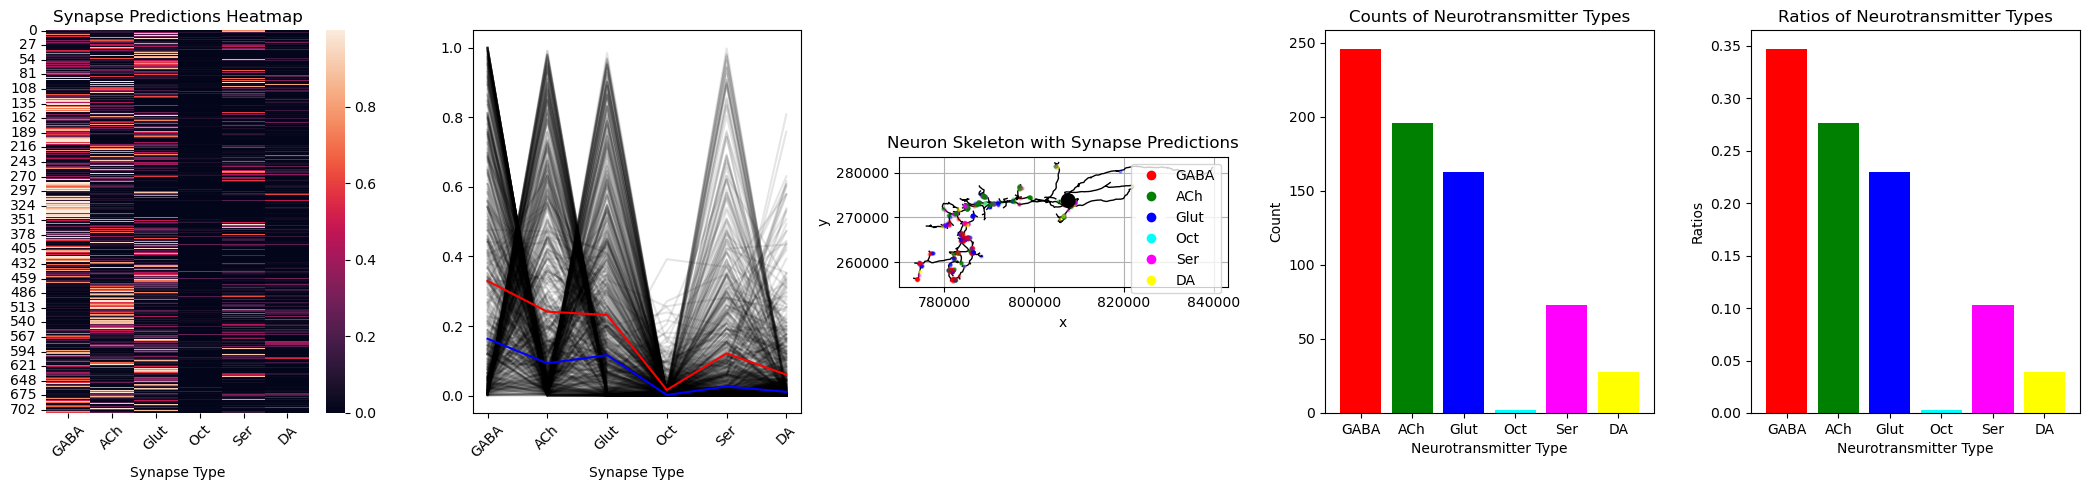

In [11]:
root_id = "720575940629900843"
pre_df, synapse_predictions = get_synapse_predictions(root_id, client)

/var/folders/6f/d2f9mt417y32sjcfd4zvfwdh0000gn/T/ipykernel_5938/362347701.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['', 'GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA'], rotation=45)


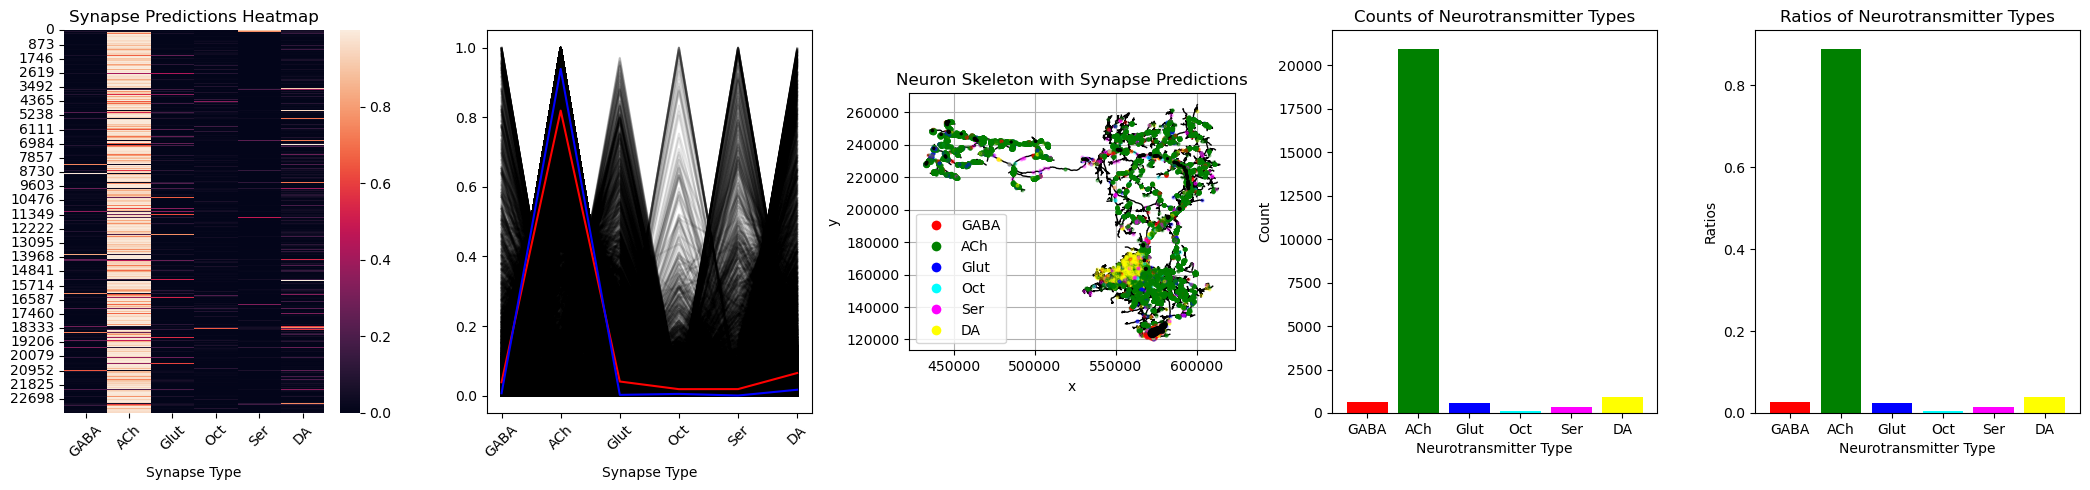

/var/folders/6f/d2f9mt417y32sjcfd4zvfwdh0000gn/T/ipykernel_5938/362347701.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['', 'GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA'], rotation=45)


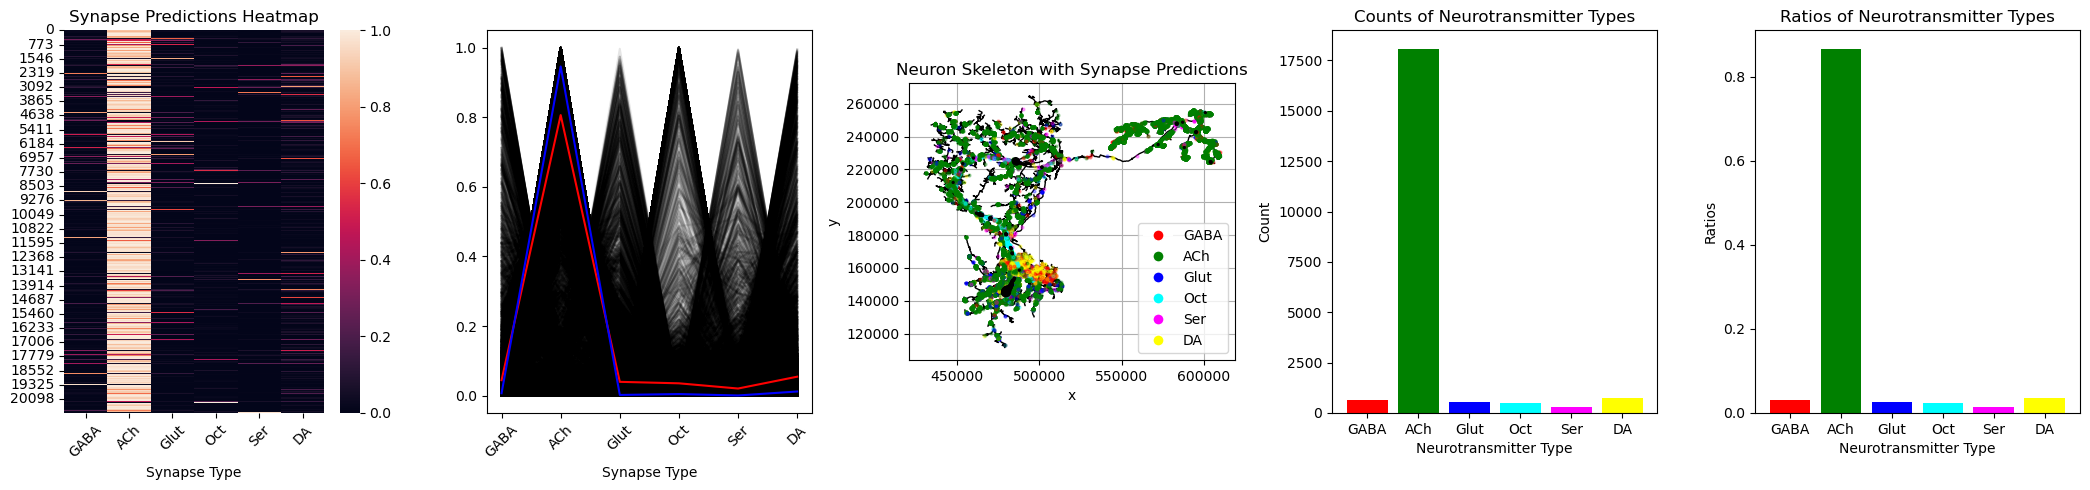

In [9]:
# MBON26
root_id = "720575940607155890"
pre_df, synapse_predictions = get_synapse_predictions(root_id, client)

root_id = "720575940629981440"
pre_df, synapse_predictions = get_synapse_predictions(root_id, client)

/var/folders/6f/d2f9mt417y32sjcfd4zvfwdh0000gn/T/ipykernel_5938/362347701.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['', 'GABA', 'ACh', 'Glut', 'Oct', 'Ser', 'DA'], rotation=45)


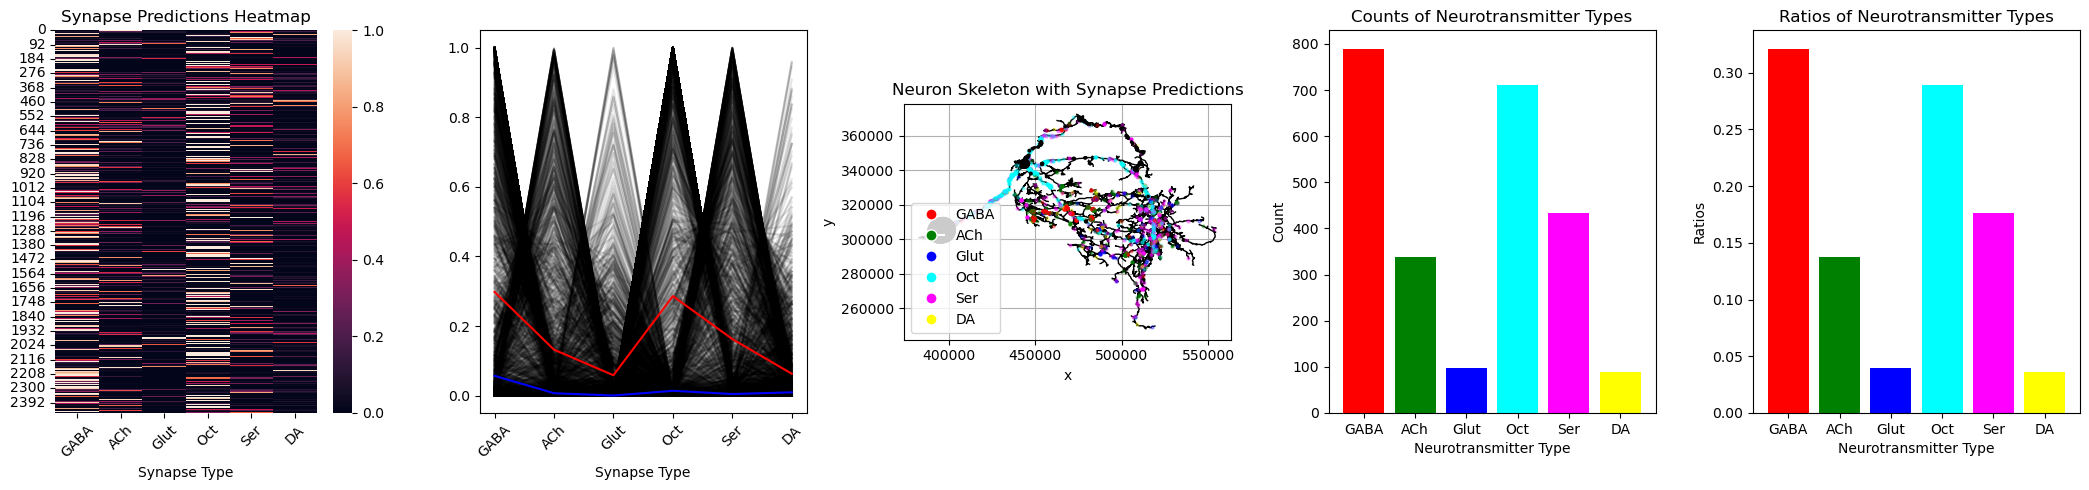

In [10]:
#DNg28
root_id = "720575940630665210"
pre_df, synapse_predictions = get_synapse_predictions(root_id, client)

In [12]:
1/6

0.16666666666666666